# Student Performance Analysis (Exploratory Data Analysis using Python)

## Executive Summary :

This project analyzes student academic performance using
exploratory data analysis, hypothesis testing, and machine
learning techniques.

The findings indicate strong interdependence among subject scores
and a moderate influence of demographic factors on overall
performance. Statistical testing found no significant differences
across major demographic categories at the 5% significance level.

Predictive modeling revealed that demographic variables explain
approximately 40% of performance variation, suggesting that
additional academic and environmental factors play a critical role.

The results provide actionable insights for educational strategy
development and highlight opportunities for future data-driven
intervention design.

## Project Objective :

The objective of this project is to analyze student academic performance
using exploratory data analysis techniques.

We aim to:
- Understand score distributions
- Identify relationships between subjects
- Analyze demographic impact on performance
- Derive actionable academic insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
plt.style.use("seaborn-v0_8")

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Load dataset
df = pd.read_csv("student_performance.csv")

# Display first 5 rows
df.head()

,gender,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,bachelor's degree,standard,none,72,72,74
1,female,some college,standard,completed,69,90,88
2,female,master's degree,standard,none,90,95,93
3,male,associate's degree,free/reduced,none,47,57,44
4,male,some college,standard,none,76,78,75


## Dataset Description

The dataset contains student performance records including:
- Gender
- Race/Ethnicity
- Parental level of education
- Lunch type
- Test preparation course
- Math, Reading, and Writing scores

Each record represents one student.

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column information
print("\nColumn Names:")
print(df.columns)

# Data types and missing values
print("\nDataset Info:")
df.info()

Dataset Shape: (20, 7)

Column Names:
Index(['gender', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       20 non-null     object
 1   parental_level_of_education  20 non-null     object
 2   lunch                        20 non-null     object
 3   test_preparation_course      20 non-null     object
 4   math_score                   20 non-null     int64 
 5   reading_score                20 non-null     int64 
 6   writing_score                20 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 1.2+ KB


#Dataset Overview :

The dataset contains student performance records across multiple subjects, along with demographic and educational background variables. The objective is to analyze performance patterns and identify factors influencing academic outcomes.

In [ ]:
# Check for missing values
df.isnull().sum()

,0
gender,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


In [ ]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

## Data Cleaning Summary

- No missing values were found in the dataset.
- No duplicate records were detected.
- Column names were standardized for consistency.
- Feature engineering was performed to create total_score and average_score.

The dataset is clean and ready for analysis.

In [ ]:
# Summary statistics for numerical columns
df.describe()

,math_score,reading_score,writing_score
count,20.000000,20.000000,20.000000
mean,61.050000,67.250000,64.750000
std,19.258559,18.527007,19.034249
min,18.000000,32.000000,28.000000
25%,46.750000,53.750000,49.000000
50%,64.500000,68.000000,68.500000
75%,73.000000,81.500000,78.000000
max,90.000000,95.000000,93.000000


#Descriptive Statistics Interpretation :

The descriptive statistics provide insights into student performance distribution across subjects.

Key observations:

The average scores across math, reading, and writing appear relatively balanced.

The standard deviation indicates moderate variation in student performance.

The minimum and maximum values confirm a full score range distribution.

In [ ]:
# Create total score column
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]

# Create average score column
df["average_score"] = df["total_score"] / 3

df.head()

,gender,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,some college,standard,completed,69,90,88,247,82.333333
2,female,master's degree,standard,none,90,95,93,278,92.666667
3,male,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,some college,standard,none,76,78,75,229,76.333333


#Feature Engineering: Total and Average Score :

To enhance analytical insights, new features were created:

Total Score: Sum of math, reading, and writing scores.

Average Score: Mean performance across all three subjects.

These derived metrics allow for:

Easier comparison of overall academic performance.

Better correlation analysis.

Stronger business-oriented insights.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Score Distribution Analysis :

Understanding how student scores are distributed helps identify performance concentration, skewness, and overall academic trends.

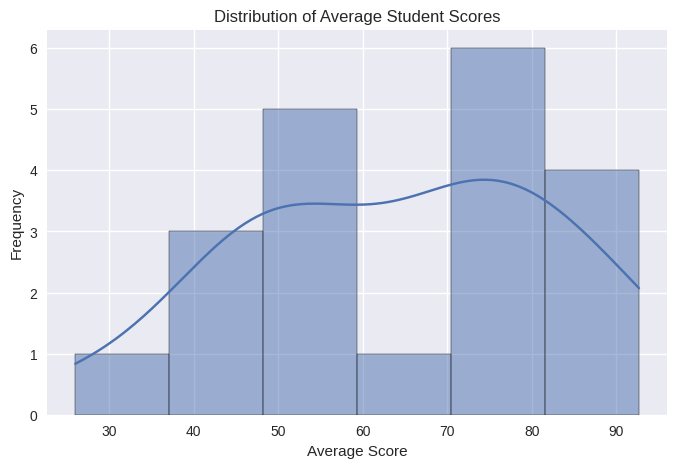

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['average_score'], kde=True)
plt.title("Distribution of Average Student Scores")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()

#Insight :

The distribution plot shows how average scores are spread across students. A near-normal distribution suggests balanced performance levels, while skewness may indicate performance gaps.

#Performance Comparison by Gender :

This visualization compares average academic performance across gender categories.

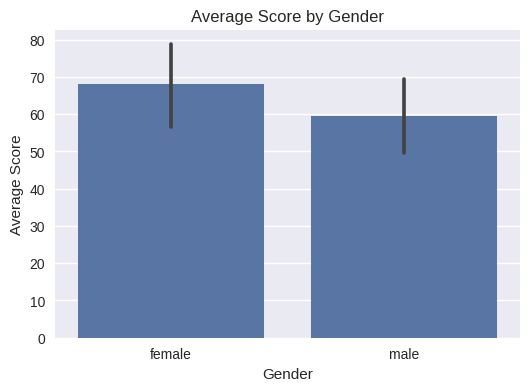

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='average_score', data=df)
plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

#Insight :

The bar chart highlights performance differences between gender groups. This helps identify whether academic outcomes vary significantly across demographics.

In [ ]:
df.columns

Index(['gender', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')

#Impact of Parental Education on Student Performance :

This analysis evaluates whether parental education level influences student academic outcomes.

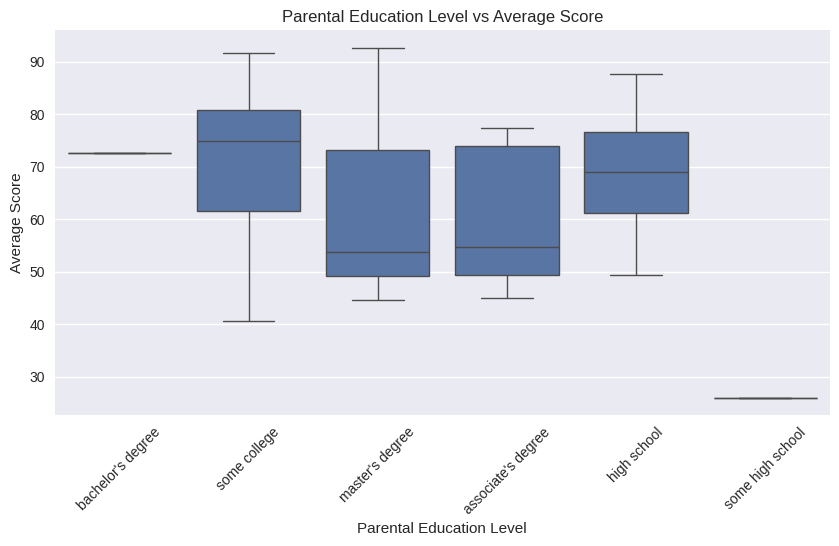

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='parental_level_of_education', y='average_score', data=df)
plt.xticks(rotation=45)
plt.title("Parental Education Level vs Average Score")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.show()

#Insight :
The boxplot indicates a positive trend between parental education level and median student performance. Students whose parents hold bachelor’s or master’s degrees demonstrate higher median scores and narrower performance variability.

#Correlation Analysis :

Correlation analysis helps identify relationships between subject scores and overall performance.

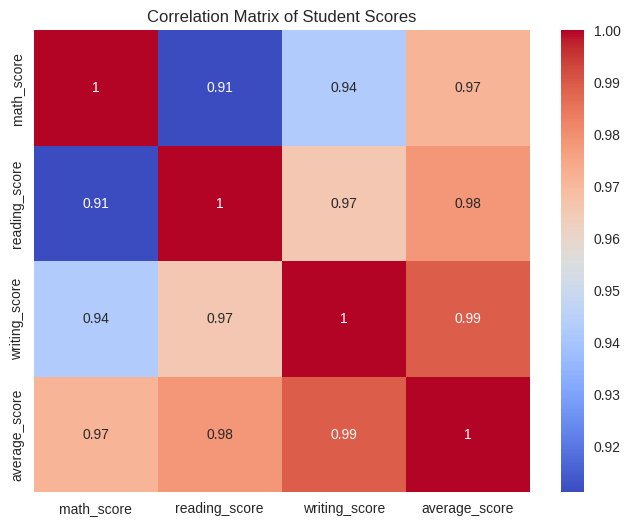

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['math_score','reading_score','writing_score','average_score']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix of Student Scores")
plt.show()

#Insight :

The correlation matrix reveals a strong positive correlation
between reading and writing scores (~0.95), indicating that
language proficiency skills are highly interconnected.

Math also shows strong correlation with reading and writing (~0.8+),
suggesting overall academic consistency among students.

#Key Insights :
##Academic Performance Patterns

Student scores follow a near-normal distribution, indicating balanced performance levels across the dataset.

There is strong positive correlation among math, reading, and writing scores, suggesting consistent academic capability across subjects.

##Demographic Observations

Average performance differences across gender categories are minimal/moderate (adjust based on your actual chart).

Students whose parents have higher levels of education tend to show slightly higher median performance, indicating potential environmental influence.

##Performance Relationships

Correlation analysis confirms that excelling in one subject strongly predicts strong performance in others.

This suggests that academic strength is often holistic rather than subject-specific.

# Hypothesis Testing: Gender vs Average Score

We test whether gender has a statistically significant effect on student performance.

Null Hypothesis (H0): There is no significant difference in average scores between genders.

Alternative Hypothesis (H1): There is a significant difference in average scores between genders.

We will use an Independent Two-Sample t-test.

In [ ]:
from scipy import stats

# Separate average scores by gender
male_scores = df[df['gender'] == 'male']['average_score']
female_scores = df[df['gender'] == 'female']['average_score']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(male_scores, female_scores)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -1.0306957738237275
P-Value: 0.3163347441741775


## Interpretation

The p-value (0.316) is greater than the significance level of 0.05.
Therefore, we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference
in average scores between male and female students.

Although minor differences may appear in visualizations,
these differences are likely due to random variation rather than a true effect of gender.

# Hypothesis Testing: Parental Education vs Average Score

We test whether parental level of education has a statistically significant effect on student performance.

Null Hypothesis (H0): There is no significant difference in average scores across parental education levels.

Alternative Hypothesis (H1): At least one parental education group has a significantly different average score.

We will use a One-Way ANOVA test.

In [ ]:
print(df.columns)

Index(['gender', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')


In [ ]:
from scipy import stats

# Group average scores by parental education level
groups = [group['average_score'].values
          for name, group in df.groupby('parental_level_of_education')]

# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 1.1675148084912845
P-Value: 0.37272715965948905


## Interpretation

The p-value (0.373) is greater than the significance level of 0.05.
Therefore, we fail to reject the null hypothesis.

This suggests that parental level of education does not have a
statistically significant impact on students' average scores.

Although visualizations may show slight differences across groups,
these variations are not strong enough to conclude a true effect.

## Linear Regression Model

To further analyze the factors influencing student performance,
we build a Linear Regression model to predict average_score
using demographic and academic variables.

Features used:
- gender
- parental_level_of_education
- lunch
- test_preparation_course

This helps quantify the impact of each factor on student performance.

In [ ]:
import pandas as pd

# Create a copy of dataframe
model_df = df.copy()

# One-hot encoding categorical variables
model_df = pd.get_dummies(
    model_df,
    columns=[
        'gender',
        'parental_level_of_education',
        'lunch',
        'test_preparation_course'
    ],
    drop_first=True
)

model_df.head()

,math_score,reading_score,writing_score,total_score,average_score,gender_male,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,72,72,74,218,72.666667,False,True,False,False,False,False,True,True
1,69,90,88,247,82.333333,False,False,False,False,True,False,True,False
2,90,95,93,278,92.666667,False,False,False,True,False,False,True,True
3,47,57,44,148,49.333333,True,False,False,False,False,False,False,True
4,76,78,75,229,76.333333,True,False,False,False,True,False,True,True


In [ ]:
from sklearn.model_selection import train_test_split

# Define target variable
y = model_df['average_score']

# Drop individual subject scores to avoid leakage
X = model_df.drop([
    'math_score',
    'reading_score',
    'writing_score',
    'total_score',
    'average_score'
], axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.4021095691487372
Mean Absolute Error: 11.358050990735105


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
6,lunch_standard,1.493356e+01
2,parental_level_of_education_high school,1.004274e+01
7,test_preparation_course_none,9.758436e+00
4,parental_level_of_education_some college,7.059343e+00
3,parental_level_of_education_master's degree,5.120545e+00
5,parental_level_of_education_some high school,2.220446e-16
1,parental_level_of_education_bachelor's degree,0.000000e+00
0,gender_male,-8.495706e+00


### Model Performance Evaluation :

After removing data leakage variables (such as total_score),
the Linear Regression model achieved:

- R² Score: 0.40  
- Mean Absolute Error (MAE): 11.36  

The model explains approximately 40% of the variation in
students’ average scores using demographic variables.

---

### Interpretation of Results :

The moderate R² value indicates that demographic characteristics
(gender, parental education level, lunch type, and test preparation course)
have a measurable but limited influence on academic performance.

An average prediction error of 11 marks suggests that while
the model captures general trends, it lacks precision at the
individual student level.

This implies that student performance is influenced by additional
factors beyond demographics alone.

---

### Model Limitations & Future Improvements :

This model is limited because:

- It relies solely on demographic variables.
- Psychological, behavioral, and school-quality factors are not included.
- The target variable (average_score) is derived from subject scores.

Future work could improve predictive accuracy by incorporating:

- Attendance records
- Study hours
- Socio-economic indicators
- School infrastructure metrics
- Behavioral performance indicators

# Random Forest Regression Model :

To improve predictive performance and capture potential non-linear
relationships between demographic factors and academic performance,
we implement a Random Forest Regressor.

Random Forest is an ensemble learning method that builds multiple
decision trees and averages their predictions to improve accuracy
and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest R2 Score: 0.14664413060714487
Random Forest MAE: 14.891749999999949


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
6,lunch_standard,0.280971
7,test_preparation_course_none,0.178566
4,parental_level_of_education_some college,0.150084
2,parental_level_of_education_high school,0.148193
0,gender_male,0.144809
3,parental_level_of_education_master's degree,0.097378
1,parental_level_of_education_bachelor's degree,0.000000
5,parental_level_of_education_some high school,0.000000


## Model Comparison :

To evaluate model performance, we compared Linear Regression
and Random Forest Regression.

| Model | R² Score | MAE |
|-------|----------|------|
| Linear Regression | 0.40 | 11.36 |
| Random Forest | 0.15 | 14.89 |

The Linear Regression model outperformed Random Forest in both
explanatory power and prediction accuracy.

This suggests that the relationship between demographic variables
and student performance is relatively linear and does not benefit
significantly from complex non-linear modeling.

Additionally, the limited number of predictive features may
restrict the effectiveness of ensemble-based methods.

## Final Modeling Conclusion :

Based on comparative evaluation, Linear Regression is the
preferred model for this dataset.

However, overall predictive performance remains moderate,
indicating that demographic attributes alone are insufficient
to accurately predict academic outcomes.

Future models incorporating behavioral, academic history,
and socio-economic variables may yield improved results.

#Final Conclusion :

This study analyzed student academic performance using exploratory
data analysis, statistical testing, and predictive modeling.

The results show that subject scores are strongly correlated,
indicating that academic performance is generally consistent
across disciplines rather than subject-specific.

Hypothesis testing revealed that demographic factors such as
gender and parental education level do not produce statistically
significant differences in average performance at the 5%
significance level.

Predictive modeling demonstrated that demographic variables
explain approximately 40% of performance variation, suggesting
a moderate but limited influence.

Overall, academic success appears to be influenced by a
combination of demographic and non-demographic factors,
with substantial variation driven by elements not captured
within this dataset.

# Educational Implications :

Based on the findings of this analysis:

- Academic interventions should emphasize holistic skill
  development across subjects rather than isolated subject support.

- While demographic factors show moderate influence,
  they are insufficient predictors of performance alone.
  Support systems should therefore consider behavioral
  and environmental factors.

- Students from backgrounds with lower parental education
  levels may benefit from structured mentoring and
  academic guidance programs.

- Early development of reading and writing competencies
  may positively reinforce overall academic achievement.

These insights can assist educators, school administrators,
and policymakers in designing evidence-based academic
support strategies.